In [1]:
import pandas as pd
import xgboost as xgb
import numpy as np
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, roc_auc_score, precision_score, recall_score, f1_score
import orjson
import neurokit2 as nk
def get_json(path):
    with open(path, 'r') as f:
        return orjson.loads(f.read())

In [2]:

# --- 1. Efficiently Load the JSON Data (Assuming JSON Lines format) ---
filepath = '../results/combined_prna_outputs.json' # Replace with your file path

raw_data = get_json(filepath)
# --- Step 2: Flatten the Nested Structure ---

In [3]:
# Rename the 'snowmed_vals' to 'snomed_vals' for consistency
for entry in raw_data:
    if 'snowmed_vals' in entry:
        entry['snomed_vals'] = entry.pop('snowmed_vals')

In [4]:
# Write the modified data back to a new JSON file
with open('../results/combined_prna_outputs_modified.json', 'w') as f:
    f.write(orjson.dumps(raw_data, option=orjson.OPT_INDENT_2).decode('utf-8'))

In [4]:
# Check for duplicate 'exam_id' in raw_data, and print out the duplicates
from collections import Counter
exam_ids = [item['exam_id'] for item in raw_data]
counts = Counter(exam_ids)
duplicates = set()
for item, count in counts.items():
    if count > 1:
        print(f"Duplicate exam_id found: {item} with count {count}")
        duplicates.add(item)


In [7]:
# Find the entries with duplicate 'exam_id'
duplicate_items = [item for item in raw_data if item['exam_id'] in duplicates]
# Sort duplicate items by 'exam_id'
duplicate_items.sort(key=lambda x: x['exam_id'])
duplicate_df = pd.DataFrame(duplicate_items)
duplicate_df 
# for item in raw_data:
#     if item['exam_id'] in duplicates:
#         print(item)
#         print("----")

,exam_id,snomed_vals,primary_id,source,chagas
0,1,"{'10370003': {'present': False, 'probability':...",ptb_1,ptb,False
1,1,"{'10370003': {'present': False, 'probability':...",ptb_1,ptb,False
2,3629,"{'10370003': {'present': False, 'probability':...",samitrop_3629,samitrop,True
3,3629,"{'10370003': {'present': False, 'probability':...",ptb_3629,ptb,False
4,4991,"{'10370003': {'present': False, 'probability':...",samitrop_4991,samitrop,True
5,4991,"{'10370003': {'present': False, 'probability':...",ptb_4991,ptb,False
6,8760,"{'10370003': {'present': False, 'probability':...",samitrop_8760,samitrop,True
7,8760,"{'10370003': {'present': False, 'probability':...",ptb_8760,ptb,False
8,18511,"{'10370003': {'present': False, 'probability':...",samitrop_18511,samitrop,True
9,18511,"{'10370003': {'present': False, 'probability':...",ptb_18511,ptb,False


In [12]:
duplicate_df.iloc[0:2]['snomed_vals'][0]

{'10370003': {'present': False, 'probability': 9.548203e-08},
 '17338001': {'present': False, 'probability': 2.2350207e-08},
 '39732003': {'present': False, 'probability': 0.0009882216},
 '47665007': {'present': False, 'probability': 1.0288709e-05},
 '59118001': {'present': False, 'probability': 1.3762499e-08},
 '59931005': {'present': False, 'probability': 9.1958536e-05},
 '63593006': {'present': False, 'probability': 0.00045753896},
 '111975006': {'present': False, 'probability': 9.029457e-06},
 '164889003': {'present': False, 'probability': 6.3141356e-06},
 '164890007': {'present': False, 'probability': 6.379803e-09},
 '164909002': {'present': False, 'probability': 3.8761794e-09},
 '164917005': {'present': False, 'probability': 0.0036717483},
 '164934002': {'present': False, 'probability': 0.004680512},
 '164947007': {'present': False, 'probability': 3.33731e-06},
 '251146004': {'present': False, 'probability': 0.0027559996},
 '270492004': {'present': False, 'probability': 7.752123e

In [15]:
duplicate_df.iloc[0:2]['snomed_vals'][1]

{'10370003': {'present': False, 'probability': 9.634956e-08},
 '17338001': {'present': False, 'probability': 2.2651866e-08},
 '39732003': {'present': False, 'probability': 0.0009857087},
 '47665007': {'present': False, 'probability': 1.0351471e-05},
 '59118001': {'present': False, 'probability': 1.3942295e-08},
 '59931005': {'present': False, 'probability': 9.272568e-05},
 '63593006': {'present': False, 'probability': 0.0004583127},
 '111975006': {'present': False, 'probability': 9.110764e-06},
 '164889003': {'present': False, 'probability': 6.342149e-06},
 '164890007': {'present': False, 'probability': 6.4579737e-09},
 '164909002': {'present': False, 'probability': 3.898527e-09},
 '164917005': {'present': False, 'probability': 0.003679794},
 '164934002': {'present': False, 'probability': 0.0047016023},
 '164947007': {'present': False, 'probability': 3.34365e-06},
 '251146004': {'present': False, 'probability': 0.0027629447},
 '270492004': {'present': False, 'probability': 7.769382e-06

In [24]:
raw_data[0]

{'exam_id': '763256',
 'chagas': False,
 'age': '21',
 'is_male': 'False',
 'nn_predicted_age': '32.933292',
 '1dAVb': 'False',
 'RBBB': 'False',
 'LBBB': 'False',
 'SB': 'False',
 'ST': 'False',
 'AF': 'False',
 'patient_id': '1217369',
 'death': 'False',
 'timey': '2.961641',
 'normal_ecg': 'False',
 'trace_file': 'exams_part1.hdf5',
 'primary_id': 'code15_763256',
 'source': 'code15',
 'snomed_vals': {'10370003': {'present': False, 'probability': 8.375992e-05},
  '111975006': {'present': False, 'probability': 0.0010521555},
  '164889003': {'present': False,
   'probability': 0.00013104455,
   'actual_present': False},
  '164890007': {'present': False, 'probability': 8.582029e-06},
  '164909002': {'present': False,
   'probability': 8.851866e-06,
   'actual_present': False},
  '164917005': {'present': False, 'probability': 0.0008262891},
  '164934002': {'present': False, 'probability': 0.0024428766},
  '164947007': {'present': False, 'probability': 1.0487474e-06},
  '17338001': {'pre

# Data loading and preprocessing

In [65]:
load_ecg_data("763256", "../training_data")[0].shape

(12, 4096)

In [ ]:
nk.ecg_delineate(nk.ecg_clean(load_ecg_data("763256", "../training_data")[0], sampling_rate=400))

Searching for 763256 in '../training_data'...
Found 763256.mat at: ../training_data/code15/code15_outputs/code15_half1/exams_part1/763256.mat


(      ECG_P_Peaks  ECG_P_Onsets  ECG_P_Offsets  ECG_Q_Peaks  ECG_R_Onsets  \
 0               0             0              0            0             0   
 1               0             0              0            0             0   
 2               0             0              0            0             0   
 3               0             0              0            0             0   
 4               0             0              0            0             0   
 ...           ...           ...            ...          ...           ...   
 4091            0             0              0            0             0   
 4092            0             0              0            0             0   
 4093            0             0              0            0             0   
 4094            0             0              0            0             0   
 4095            0             0              0            0             0   
 
       ECG_R_Offsets  ECG_S_Peaks  ECG_T_Peaks  ECG_T_Onsets  

## Feature Creation

In [3]:
import pandas as pd
import numpy as np
import neurokit2 as nk
from scipy.stats import shapiro
import pywt

# =============================================================================
# Optimized Helper Functions for Feature Calculation
# =============================================================================

def calculateApproxEntropy(ecg_signal):
    """
    Calculates the approximate entropy of the ECG signal.
    A simple wrapper for the NeuroKit2 function.
    """
    if not isinstance(ecg_signal, (np.ndarray, pd.Series)) or len(ecg_signal) == 0:
        return np.nan
    try:
        # nk.entropy_approximate returns a tuple (ApEn, info_dict)
        return nk.entropy_approximate(ecg_signal)[0]
    except Exception:
        return np.nan

def calculateSampleEntropy(ecg_signal):
    """
    Calculates the sample entropy of the ECG signal.
    A simple wrapper for the NeuroKit2 function.
    """
    if not isinstance(ecg_signal, (np.ndarray, pd.Series)) or len(ecg_signal) == 0:
        return np.nan
    try:
        # nk.entropy_sample returns a tuple (SampEn, info_dict)
        return nk.entropy_sample(ecg_signal)[0]
    except Exception:
        return np.nan

def calculate_swt_entropy_optimized(signal, wavelet='db4', level=4):
    """
    Calculates Shannon Entropy of a specific SWT decomposition level using a
    faster NumPy-based method.

    Args:
        signal (array): The input signal segment.
        wavelet (str): The type of wavelet to use.
        level (int): The decomposition level to analyze.

    Returns:
        float: The Shannon Entropy of the specified level's detail coefficients.
    """
    try:
        # Perform SWT decomposition
        coeffs = pywt.swt(signal, wavelet=wavelet, level=level)
        # We are interested in the detail coefficients of the target level.
        detail_coeffs = coeffs[-level][1]

        # OPTIMIZATION: Use np.unique for faster probability distribution calculation
        _, counts = np.unique(detail_coeffs, return_counts=True)
        probabilities = counts / len(detail_coeffs)
        
        # Calculate entropy
        entropy = -np.sum(probabilities * np.log2(probabilities))
        return entropy
    except Exception:
        return np.nan

def calculate_permutation_entropy(signal, dimension=3, delay=1, scale=1):
    """
    Calculates permutation entropy, with a scaling factor for multiscale analysis.

    Args:
        signal (array): The input signal segment.
        dimension (int): The embedding dimension.
        delay (int): The time delay.
        scale (int): The scale factor for multiscale entropy.

    Returns:
        float: The calculated permutation entropy.
    """
    try:
        if scale > 1:
            signal = nk.signal_coarsegrain(signal, scale=scale)
        
        # CORRECTED: Unpack the tuple correctly
        p_entropy, _ = nk.entropy_permutation(signal, dimension=dimension, delay=delay, corrected=True)
        return p_entropy
    except Exception:
        return np.nan

def calculate_fisher_information(rr_intervals):
    """
    Estimates the Fisher Information for the RR interval series, assuming
    it follows a normal distribution.

    Args:
        rr_intervals (array): The series of RR intervals.

    Returns:
        float: The estimated Fisher Information.
    """
    # Shapiro-Wilk test requires at least 3 samples
    if len(rr_intervals) < 3:
        return np.nan
        
    _, p_value = shapiro(rr_intervals)

    # Proceed if the data is not significantly different from normal (p > 0.05)
    if p_value > 0.05:
        variance = np.var(rr_intervals)
        if variance > 0:
            # Fisher Information for the mean of a Gaussian is 1 / variance
            return 1 / variance
    return np.nan # Return NaN if not normally distributed or variance is zero

# =============================================================================
# Main Optimized Feature Calculation Function
# =============================================================================

def calculate_ecg_features_from_12_leads(ecg_12_leads, sampling_rate):
    """
    Optimized calculation of focused ECG features from a 12-lead signal.
    This version centralizes signal processing and uses vectorized operations for speed.

    Args:
        ecg_12_leads (DataFrame or ndarray): DataFrame or array with 12 rows (leads)
                                             or 12 columns.
        sampling_rate (int): The sampling frequency (in Hz).

    Returns:
        dict: A dictionary of the calculated feature values.
    """
    # --- Step 0: Initialization and Data Preparation ---
    feature_names = [
        'HR_min', 'HR_max', 'RMSSD', 'P_Wave_Correlation_Coefficient', 
        'RR_Interval_Median', 'Heart_Rate_mu', 'RR_Interval_Fisher_Info', 
        'pNN60', 'Heart_Rate_Activity', 'Delta_RR_min', 
        'P_Wave_Sample_Entropy_sigma', 'Median_P_Wave_Approximate_Entropy',
        'R_Peak_Approximate_Entropy'
    ]
    features = {name: np.nan for name in feature_names}

    if isinstance(ecg_12_leads, pd.DataFrame):
        ecg_12_leads = ecg_12_leads.values
    
    # Ensure data is in (leads, samples) format
    if ecg_12_leads.shape[1] == 12:
       ecg_12_leads = ecg_12_leads.T

    # Select Lead II for primary analysis
    signal_lead_II = ecg_12_leads[1, :]

    # --- FIX: Sanitize input signal to handle potential NaN values ---
    signal_series = pd.Series(signal_lead_II)
    if signal_series.isnull().any():
        signal_series = signal_series.interpolate(method='linear', limit_direction='both')
    signal_lead_II = signal_series.values
    # --- End of fix ---


    # --- Step 1: Centralized Cleaning and R-Peak Detection (MAJOR OPTIMIZATION) ---
    try:
        ecg_cleaned = nk.ecg_clean(signal_lead_II, sampling_rate=sampling_rate)
        
        _, rpeaks_info = nk.ecg_peaks(ecg_cleaned, sampling_rate=sampling_rate, correct_artifacts=True)
        rpeaks = rpeaks_info['ECG_R_Peaks']
        
        if len(rpeaks) < 4:
            return features
            
    except Exception as e:
        print(f"Critical Error in initial processing of Lead II: {e}. Cannot proceed.")
        return features

    # --- Step 2: HRV Feature Calculation (using pre-computed R-peaks) ---
    hr = nk.ecg_rate(rpeaks, sampling_rate=sampling_rate, desired_length=len(ecg_cleaned))
    
    valid_hr = hr[~np.isnan(hr)]
    if valid_hr.size > 0:
        features['HR_min'] = np.min(valid_hr)
        features['HR_max'] = np.max(valid_hr)
        features['Heart_Rate_mu'] = np.mean(valid_hr)
        features['Heart_Rate_Activity'] = np.std(valid_hr)
    
    hrv_time = nk.hrv_time(rpeaks, sampling_rate=sampling_rate, show=False)
    if hrv_time is not None and not hrv_time.empty: 
        features['RMSSD'] = hrv_time['HRV_RMSSD'].iloc[0]
    
    rr_intervals_ms = np.diff(rpeaks) / sampling_rate * 1000
    features['RR_Interval_Median'] = np.median(rr_intervals_ms)
    features['RR_Interval_Fisher_Info'] = calculate_fisher_information(rr_intervals_ms)
    
    if len(rr_intervals_ms) > 1:
        nn_diff = np.abs(np.diff(rr_intervals_ms))
        features['pNN60'] = (np.sum(nn_diff > 60) / len(nn_diff)) * 100
        features['Delta_RR_min'] = np.min(nn_diff)
    
    features['R_Peak_Approximate_Entropy'] = calculateApproxEntropy(rr_intervals_ms)

    # --- Step 3: Efficient P-Wave Analysis (using cleaned signal and R-peaks) ---
    try:
        _, waves = nk.ecg_delineate(ecg_cleaned, rpeaks, sampling_rate=sampling_rate, method="dwt")
        
        p_onsets = waves['ECG_P_Onsets']
        p_offsets = waves['ECG_P_Offsets']
        
        p_waves = [ecg_cleaned[int(on):int(off)] for on, off in zip(p_onsets, p_offsets)
                   if not np.isnan(on) and not np.isnan(off) and off > on and (off - on) > 5]

        if p_waves:
            p_apens = [calculateApproxEntropy(p) for p in p_waves]
            p_sampens = [calculateSampleEntropy(p) for p in p_waves]
            
            valid_p_apens = [e for e in p_apens if not np.isnan(e)]
            if valid_p_apens: features['Median_P_Wave_Approximate_Entropy'] = np.median(valid_p_apens)
            
            # --- FIX: More robust filtering for std calculation ---
            valid_p_sampens = [e for e in p_sampens if np.isfinite(e)]
            if len(valid_p_sampens) > 1: 
                features['P_Wave_Sample_Entropy_sigma'] = np.std(valid_p_sampens)
            # --- End of fix ---

            median_len = int(np.median([len(p) for p in p_waves]))
            if median_len > 0:
                resampled_waves = np.array([nk.signal_resample(p, desired_length=median_len) for p in p_waves])
                
                # --- FIX: Use nanmean to avoid RuntimeWarning ---
                template_p = np.nanmean(resampled_waves, axis=0)
                
                resampled_centered = resampled_waves - np.nanmean(resampled_waves, axis=1, keepdims=True)
                template_centered = template_p - np.nanmean(template_p)
                # --- End of fix ---
                
                numerator = np.nansum(resampled_centered * template_centered, axis=1)
                denominator = np.sqrt(np.nansum(resampled_centered**2, axis=1) * np.nansum(template_centered**2))
                
                valid_denominators = denominator > 0
                corrs = np.full(len(p_waves), np.nan)
                corrs[valid_denominators] = numerator[valid_denominators] / denominator[valid_denominators]
                
                features['P_Wave_Correlation_Coefficient'] = np.nanmean(corrs)
                
    except Exception:
        pass

    return features


In [54]:
calculate_ecg_features_from_12_leads(load_ecg_data("00055_hr", "../training_data")[0], 500) # ptb

{'HR_min': 66.96428571428571,
 'HR_max': 89.02077151335311,
 'RMSSD': 65.71757755730198,
 'P_Wave_Correlation_Coefficient': 0.9475928701413546,
 'RR_Interval_Median': 826.0,
 'Heart_Rate_mu': 72.08570981597138,
 'RR_Interval_Fisher_Info': 0.0002898509064428347,
 'pNN60': 10.0,
 'Heart_Rate_Activity': 3.860488399245029,
 'Delta_RR_min': 6.0,
 'P_Wave_Sample_Entropy_sigma': 0.030508906986557498,
 'Median_P_Wave_Approximate_Entropy': 0.2125259778058879,
 'R_Peak_Approximate_Entropy': 0.03326892045416274}

In [55]:
calculate_ecg_features_from_12_leads(load_ecg_data("678293", "../training_data")[0], 400) # samitrop

{'HR_min': 61.53846153846154,
 'HR_max': 62.5,
 'RMSSD': 6.373774391990981,
 'P_Wave_Correlation_Coefficient': 0.8752402190616503,
 'RR_Interval_Median': 967.5,
 'Heart_Rate_mu': 62.04245040011322,
 'RR_Interval_Fisher_Info': 0.05764705882352941,
 'pNN60': 0.0,
 'Heart_Rate_Activity': 0.23219916381516273,
 'Delta_RR_min': 0.0,
 'P_Wave_Sample_Entropy_sigma': 0.07146108989526262,
 'Median_P_Wave_Approximate_Entropy': 0.2265460689195704,
 'R_Peak_Approximate_Entropy': 0.18232155679395445}

In [4]:
def calculate_ecg_features(ecg_signal, sampling_rate):
    """
    Processes a single-lead ECG signal using NeuroKit2 and calculates aggregated features.

    This function addresses common issues like missing delineations by carefully
    handling potential KeyErrors and NaN values, preventing runtime warnings and crashes.

    Args:
        ecg_signal (array): The raw ECG signal as a 1D NumPy array.
        sampling_rate (int): The sampling rate of the ECG signal (in Hz).

    Returns:
        dict: A dictionary containing the calculated aggregated features for a single lead.
              Returns an empty dict if processing fails.
    """

    # --- Step 1: Process the ECG Signal using NeuroKit2 ---
    try:
        # Process the signal to find R-peaks
        signals, info = nk.ecg_process(ecg_signal, sampling_rate=sampling_rate)
        r_peaks = info["ECG_R_Peaks"]
        # Exit if no R-peaks were found, as delineation is not possible
        if len(r_peaks) == 0:
            print("Warning: No R-peaks found in the signal. Cannot calculate features.")
            return {}
    except Exception as e:
        print(f"An error occurred during NeuroKit2 processing: {e}")
        return {}

    # --- Step 2: Delineate Waveforms ---
    # The `dwt` method is generally robust, but may still fail on noisy signals.
    try:
        _, waves = nk.ecg_delineate(ecg_signal, r_peaks, sampling_rate=sampling_rate, method="dwt")
    except Exception as e:
        print(f"An error occurred during ECG delineation: {e}. Cannot calculate features.")
        return {}

    # --- Step 3: Calculate QRS Duration for Each Beat (Robustly) ---
    qrs_onsets = waves.get('ECG_R_Onsets', [])
    qrs_offsets = waves.get('ECG_R_Offsets', [])

    all_qrs_durations_ms = []
    if qrs_onsets and qrs_offsets:
        for onset, offset in zip(qrs_onsets, qrs_offsets):
            if pd.notna(onset) and pd.notna(offset):
                duration_samples = offset - onset
                duration_ms = (duration_samples / sampling_rate) * 1000
                all_qrs_durations_ms.append(duration_ms)

    # # --- Step 4: Calculate Pathological Q-Waves (Placeholder) ---
    # # NOTE: The 'dwt' method in Neurokit2 does not delineate individual Q and S waves.
    # # This calculation is a placeholder and will result in 0. For accurate Q-wave
    # # analysis, a different delineation method or a custom algorithm would be needed.
    # _, peak_waves = nk.ecg_delineate(ecg_signal, r_peaks, sampling_rate=sampling_rate, method="peak")
    # q_peaks = peak_waves.get('ECG_Q_Peaks', [])
    # r_onsets = peak_waves.get('ECG_R_Onsets', [])

    # pathological_q_waves_count = 0
    # valid_q_waves = 0
    # if q_peaks and r_onsets:
    #     for q_peak, r_onset in zip(q_peaks, r_onsets):
    #         # Example logic (will not run with 'dwt' method)
    #         # This is a conceptual placeholder
    #         if pd.notna(q_peak) and pd.notna(r_onset):
    #             valid_q_waves += 1
    #             q_duration_ms = ((r_onset - q_peak) / sampling_rate) * 1000 # Simplified logic
    #             if q_duration_ms > 40: # Pathological if > 40ms
    #                 pathological_q_waves_count += 1

    # percentage_path_q = (pathological_q_waves_count / valid_q_waves * 100) if valid_q_waves > 0 else 0

    # --- Step 5: Calculate ST Segment Deviation (Robustly) ---
    # Using J-point (approximated by T-wave onset) relative to isoelectric line (approximated by QRS onset)
    t_onsets = waves.get('ECG_T_Onsets', []) # T-onset is often used as a proxy for J-point
    all_st_deviations = []

    if qrs_onsets and t_onsets:
        for qrs_onset, t_onset in zip(qrs_onsets, t_onsets):
            # Ensure indices are valid and within the signal bounds
            if pd.notna(qrs_onset) and pd.notna(t_onset) and int(qrs_onset) < len(ecg_signal) and int(t_onset) < len(ecg_signal):
                # Isoelectric level is approximated at the QRS onset
                isoelectric_level = ecg_signal[int(qrs_onset)]
                # J-point level is approximated at the T-wave onset
                j_point_level = ecg_signal[int(t_onset)]
                # Deviation is the difference in amplitude
                st_deviation = j_point_level - isoelectric_level
                all_st_deviations.append(st_deviation)

    # Convert lists to numpy arrays for safe statistical calculation
    all_qrs_durations_ms = np.array(all_qrs_durations_ms)
    all_st_deviations = np.array(all_st_deviations)

    # --- Step 6: Aggregate Features and Handle Potential Empty Slices ---
    features = {
        "mean_qrs_duration": np.mean(all_qrs_durations_ms) if len(all_qrs_durations_ms) > 0 else np.nan,
        "max_qrs_duration": np.max(all_qrs_durations_ms) if len(all_qrs_durations_ms) > 0 else np.nan,
        "std_qrs_duration": np.std(all_qrs_durations_ms) if len(all_qrs_durations_ms) > 0 else np.nan,
        # "n_pathological_q": pathological_q_waves_count,
        # "percentage_q_wave": percentage_path_q,
        "mean_st_deviation": np.mean(all_st_deviations) if len(all_st_deviations) > 0 else np.nan,
        "max_st_elevation": np.max(all_st_deviations[all_st_deviations > 0]) if len(all_st_deviations[all_st_deviations > 0]) > 0 else 0,
        "max_st_depression": np.min(all_st_deviations[all_st_deviations < 0]) if len(all_st_deviations[all_st_deviations < 0]) > 0 else 0,
    }

    return features

def process_12_lead_ecg(ecg_signals_12_leads, sampling_rate, lead_names=None):
    """
    Processes a 12-lead ECG to generate a comprehensive set of features, including
    both per-lead statistics and global summary statistics.

    Args:
        ecg_signals_12_leads (list of array): A list of 12 ECG signals (1D NumPy arrays).
        sampling_rate (int): The sampling rate of the ECG signals (in Hz).
        lead_names (list of str, optional): Names for the 12 leads.
                                            Defaults to standard ECG lead names.

    Returns:
        dict: A single, flat dictionary containing all calculated features.
    """
    if lead_names is None:
        lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

    if len(ecg_signals_12_leads) != len(lead_names):
        raise ValueError("The number of ECG signals must match the number of lead names.")

    all_features = {}
    per_lead_features_list = []

    # --- Step 1: Calculate Per-Lead Features ---
    # This preserves the critical, localized information from each lead.
    # for i, ecg_signal in enumerate(ecg_signals_12_leads):
    #     lead_name = lead_names[i]
    #     # print(f"Processing Lead: {lead_name}...")

    #     # Calculate features for the single lead
    #     single_lead_features = calculate_ecg_features(ecg_signal, sampling_rate)
    #     per_lead_features_list.append(single_lead_features)

    #     # Add the features to the main dictionary with a lead-specific prefix
    #     for key, value in single_lead_features.items():
    #         all_features[f"lead_{lead_name}_{key}"] = value

    # # --- Step 2: Calculate Global Summary Statistics ---
    # # These features provide a high-level overview of the entire ECG.
    # # We use nan-safe operations to handle cases where a lead might fail processing.
    # all_features['global_mean_qrs_duration'] = np.nanmean([f.get('mean_qrs_duration', np.nan) for f in per_lead_features_list])
    # all_features['global_max_qrs_duration'] = np.nanmax([f.get('max_qrs_duration', np.nan) for f in per_lead_features_list if f])
    # all_features['global_max_st_elevation'] = np.nanmax([f.get('max_st_elevation', np.nan) for f in per_lead_features_list if f])
    # all_features['global_max_st_depression'] = np.nanmin([f.get('max_st_depression', np.nan) for f in per_lead_features_list if f])
    # all_features['global_total_pathological_q'] = np.nansum([f.get('n_pathological_q', 0) for f in per_lead_features_list if f])

    # --- Step 3 (Optional): Add other 12-lead features ---
    # You can add calls to other feature extraction functions here if needed.
    # For example, if you have a function for entropy or other complex features:
    all_features.update(calculate_ecg_features_from_12_leads(ecg_signals_12_leads, sampling_rate))

    return all_features

In [33]:
process_12_lead_ecg(load_ecg_data("00825_hr", "../training_data")[0], 500) # ptb

/sailhome/kelvinkn/juice/miniconda3/envs/physionet/lib/python3.9/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


{'lead_I_mean_qrs_duration': 149.27272727272728,
 'lead_I_max_qrs_duration': 218.0,
 'lead_I_std_qrs_duration': 39.673877160237566,
 'lead_I_mean_st_deviation': -23.545454545454547,
 'lead_I_max_st_elevation': 27,
 'lead_I_max_st_depression': -67,
 'lead_II_mean_qrs_duration': 137.84615384615384,
 'lead_II_max_qrs_duration': 210.0,
 'lead_II_std_qrs_duration': 28.505994386730862,
 'lead_II_mean_st_deviation': -53.0,
 'lead_II_max_st_elevation': 49,
 'lead_II_max_st_depression': -127,
 'lead_III_mean_qrs_duration': 86.0,
 'lead_III_max_qrs_duration': 118.0,
 'lead_III_std_qrs_duration': 29.257477676655586,
 'lead_III_mean_st_deviation': -230.92307692307693,
 'lead_III_max_st_elevation': 40,
 'lead_III_max_st_depression': -868,
 'lead_aVR_mean_qrs_duration': 91.07692307692308,
 'lead_aVR_max_qrs_duration': 150.0,
 'lead_aVR_std_qrs_duration': 29.82632172185537,
 'lead_aVR_mean_st_deviation': 32.07692307692308,
 'lead_aVR_max_st_elevation': 212,
 'lead_aVR_max_st_depression': -805,
 'lead

# Finding ECGS

In [5]:
import os
import scipy.io
from typing import Dict, Any, Optional

def load_ecg_data(
    exam_id: str,
    search_directory: str,
    source: Optional[str] = None,
    verbose: bool = False
) -> Optional[Dict[str, Any]]:
    """
    Recursively searches for an ECG data file (.mat) corresponding to a given
    exam_id and returns the loaded data. An optional source parameter can be
    provided to specify a subdirectory within the search_directory.

    Args:
        exam_id: The identifier of the exam.
        search_directory: The root directory to start the search from.
        source: An optional subdirectory within search_directory to limit the search.

    Returns:
        Tuple of .mat file data, and the .hea filename if found, otherwise None.
    """
    mat_filename = f"{exam_id}.mat"
    hea_filename = f"{exam_id}.hea"

    # Construct the final search path
    effective_search_path = search_directory
    if source:
        effective_search_path = os.path.join(search_directory, source)

    # Check if the effective search path exists
    if not os.path.isdir(effective_search_path):
        print(f"Error: Search path does not exist: {effective_search_path}")
        return None

    if verbose:
        print(f"Searching for {exam_id} in '{effective_search_path}'...")
    for dirpath, _, filenames in os.walk(effective_search_path):
        if mat_filename in filenames and hea_filename in filenames:
            mat_filepath = os.path.join(dirpath, mat_filename)
            try:
                if verbose:
                    print(f"Found {mat_filename} at: {mat_filepath}")
                # Load the .mat file
                mat_data = scipy.io.loadmat(mat_filepath)
                return mat_data['val'], os.path.join(dirpath, hea_filename)
            except Exception as e:
                print(f"Error loading {mat_filepath}: {e}")
                return None
    
    print(f"No .mat and .hea files found for exam_id: {exam_id} in the specified path.")
    return None

## Creating the processed records

In [5]:
import sys
sys.path.append("../") # Or os.path.dirname(script_dir) if helper_code is up one level
import helper_code
processed_records = []
error_records = []
for record in raw_data:
    # Start a new dictionary for the flattened record
    # Include any other top-level data you need, like an ID or the target variable
    flat_record = {
        'primary_id': record['primary_id'],
        'chagas': record['chagas']
    }
    # Iterate through the list of SNOMED code dictionaries
    snomed_vals = None
    if "snowmed_vals"  in record:
        snomed_vals = record['snowmed_vals']
    else:
        snomed_vals = record['snomed_vals']

    for snomed_item in snomed_vals:
        # The key is the SNOMED code (e.g., "44054006")
        snomed_code = snomed_item
        # The value is the "present" boolean|
        is_present = snomed_vals[snomed_code]['present']

        # Add the SNOMED code as a feature, converting boolean to 0 or 1
        flat_record[snomed_code] = int(is_present)
        source = record['source']

        # signal, header_path = load_ecg_data(record['exam_id'], "../training_data", source)
        # frequency = int(helper_code.get_sampling_frequency(helper_code.load_header(header_path)))
        # extra_features = process_12_lead_ecg(signal, frequency)
        # flat_record.update(extra_features)

    processed_records.append(flat_record)

In [8]:
processed_records[0].keys()

dict_keys(['primary_id', 'chagas', '10370003', '111975006', '164889003', '164890007', '164909002', '164917005', '164934002', '164947007', '17338001', '251146004', '270492004', '284470004', '39732003', '426177001', '426627000', '426783006', '427084000', '427172004', '427393009', '445118002', '47665007', '59118001', '59931005', '63593006', '698252002', '713426002', '713427006'])

## Create the records with paralleization

In [7]:
import multiprocessing
import os
import sys
sys.path.append("../") # Or os.path.dirname(script_dir) if helper_code is up one level
import helper_code
from tqdm import tqdm
# Assuming load_ecg_data and process_12_lead_ecg are defined elsewhere
# (Ensure they are importable or globally available for the worker processes)

# --- New function to process a single record ---
def process_single_record(record):
    """
    Processes a single 'record' from raw_data, including SNOMED codes
    and ECG signal processing, returning a single flat_record dictionary.
    This function will be run in parallel for each record.
    """
    flat_record = {}

    # Process SNOMED values for this record
    snomed_vals = record.get('snomed_vals', {}) # Use .get() for safety
    for snomed_code, data in snomed_vals.items():
        is_present = data['present']
        flat_record[snomed_code] = int(is_present)

    # Process ECG data for this record
    source = record['source']
    exam_id = record['exam_id']
    flat_record['primary_id'] = record['primary_id']
    flat_record['chagas'] = record['chagas']

    signal, header_path = load_ecg_data(exam_id, "../training_data", source)
    frequency = int(helper_code.get_sampling_frequency(helper_code.load_header(header_path)))
    
    # This is the potentially long-running part
    extra_features = process_12_lead_ecg(signal, frequency)

    # Append the extra_features to the flat_record
    # IMPORTANT: Ensure extra_features is a dictionary to be merged.
    # If not, adjust this line based on its structure (e.g., flat_record['ecg_features'] = extra_features)
    if isinstance(extra_features, dict):
        flat_record.update(extra_features)
    else:
        # Handle cases where extra_features is not a dictionary.
        # For example, if it's a list:
        # flat_record['processed_ecg_features'] = extra_features
        # Or if it's a single value:
        # flat_record['single_ecg_feature'] = extra_features
        # For now, let's assume it's a dict or raises an error if not handled.
        print(f"Warning: extra_features for {exam_id} is not a dict. Type: {type(extra_features)}")
        # You might want to log this or decide on a specific key to assign it
        flat_record['processed_ecg_output'] = extra_features


    return flat_record

# --- Main parallel processing function ---
def parallelize_ecg_processing(raw_data):
    """
    Takes a list of 'record' dictionaries and processes them in parallel.
    """
    # Determine the number of processes to use.
    # It's common to use `os.cpu_count()` or `os.cpu_count() - 1`
    # to leave one core free for other system tasks.
    num_processes = os.cpu_count()-3 if os.cpu_count() else 4 # Default to 4 if cannot determine
    num_records = len(raw_data)

    print(f"Starting parallel processing of {len(raw_data)} records with {num_processes} processes...")

    try:
        all_flat_records = []
        with multiprocessing.Pool(processes=num_processes) as pool:
            for flat_record in tqdm(pool.imap(process_single_record, raw_data), total=num_records, desc="Processing ECG Records"):
                # Append "primary_id" and "chagas" to the flat_record
                all_flat_records.append(flat_record)

        print("Parallel processing complete.")
    except KeyboardInterrupt:
        print("Processing interrupted by user, returning what is processed so far.")
        return all_flat_records
    return all_flat_records

In [19]:
import collections
import decimal
decimal.getcontext().prec = 30 

def create_stratified_sample(data: list, stratify_column: str, sample_size: int) -> list:
    """
    Creates a stratified sample from a list of dictionaries without using pandas.

    This function ensures the distribution of values in the 'stratify_column' is
    maintained in the resulting sample. It works directly with list and dict objects,
    preserving the full internal structure of each record.

    Args:
        data (list): The original list of dictionary records.
        stratify_column (str): The dictionary key to stratify by (e.g., "chagas").
        sample_size (int): The desired number of records in the final sample.

    Returns:
        list: A new list containing the stratified sample of dictionaries.
    """
    if not data:
        return []

    # 1. Calculate the distribution of the stratification column
    total_records = len(data)
    if sample_size > total_records:
        print("Warning: Sample size is larger than the dataset. Returning the original data.")
        return data
        
    distribution = collections.Counter(record[stratify_column] for record in data)

    # 2. Determine the target count for each category in the new sample
    target_counts = {}
    for value, count in distribution.items():
        proportion = decimal.Decimal(count) / decimal.Decimal(total_records)
        target_counts[value] = int(proportion * decimal.Decimal(sample_size))

    # Adjust for rounding errors to ensure the sample size is met exactly
    current_sample_size = sum(target_counts.values())
    remainder = sample_size - current_sample_size
    if remainder > 0:
        # Distribute the remainder to the most frequent categories
        for value, _ in distribution.most_common(remainder):
            target_counts[value] += 1

    # 3. Build the stratified sample by iterating through the original data
    stratified_sample = []
    # Keep track of how many of each category we've added
    sample_current_counts = collections.Counter()

    for record in data:
        value = record[stratify_column]
        # Check if we still need records for this category
        if sample_current_counts[value] < target_counts[value]:
            # Append the entire, original dictionary record
            stratified_sample.append(record)
            sample_current_counts[value] += 1
        
        # Optimization: Stop iterating once the sample is full
        if len(stratified_sample) == sample_size:
            break
            
    return stratified_sample
strat_sample = create_stratified_sample(raw_data, 'chagas', 300000)


In [66]:
raw_data[0]

{'exam_id': '763256',
 'snowmed_vals': {'10370003': {'present': False, 'probability': 8.375992e-05},
  '111975006': {'present': False, 'probability': 0.0010521555},
  '164889003': {'present': False,
   'probability': 0.00013104455,
   'actual_present': False},
  '164890007': {'present': False, 'probability': 8.582029e-06},
  '164909002': {'present': False,
   'probability': 8.851866e-06,
   'actual_present': False},
  '164917005': {'present': False, 'probability': 0.0008262891},
  '164934002': {'present': False, 'probability': 0.0024428766},
  '164947007': {'present': False, 'probability': 1.0487474e-06},
  '17338001': {'present': False, 'probability': 0.00014215765},
  '251146004': {'present': False, 'probability': 0.0034488987},
  '270492004': {'present': False,
   'probability': 0.00011326568,
   'actual_present': False},
  '284470004': {'present': False, 'probability': 0.0012743335},
  '39732003': {'present': False, 'probability': 3.1129424e-05},
  '426177001': {'present': False,
 

In [13]:
all_flat_records[0]

{'10370003': 0,
 '111975006': 0,
 '164889003': 0,
 '164890007': 0,
 '164909002': 0,
 '164917005': 0,
 '164934002': 0,
 '164947007': 0,
 '17338001': 0,
 '251146004': 0,
 '270492004': 0,
 '284470004': 0,
 '39732003': 0,
 '426177001': 0,
 '426627000': 0,
 '426783006': 1,
 '427084000': 0,
 '427172004': 0,
 '427393009': 0,
 '445118002': 0,
 '47665007': 0,
 '59118001': 0,
 '59931005': 0,
 '63593006': 0,
 '698252002': 0,
 '713426002': 0,
 '713427006': 0,
 'primary_id': 'code15_763256',
 'chagas': False,
 'HR_min': 83.62369337979094,
 'HR_max': 92.66409266409266,
 'RMSSD': 22.26371660175086,
 'P_Wave_Correlation_Coefficient': 0.9798521180484205,
 'RR_Interval_Median': 680.0,
 'Heart_Rate_mu': 88.19368415390063,
 'RR_Interval_Fisher_Info': 0.003247721623860812,
 'pNN60': 0.0,
 'Heart_Rate_Activity': 1.9882353951573895,
 'Delta_RR_min': 2.5,
 'P_Wave_Sample_Entropy_sigma': 0.034418208178755384,
 'Median_P_Wave_Approximate_Entropy': 0.15736060709683564,
 'R_Peak_Approximate_Entropy': 0.0265953201

In [20]:
all_flat_records = parallelize_ecg_processing(strat_sample)

Starting parallel processing of 300000 records with 29 processes...


Processing ECG Records:   0%|          | 68/300000 [00:02<1:55:10, 43.40it/s] /sailhome/kelvinkn/juice/miniconda3/envs/physionet/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
Processing ECG Records:   0%|          | 77/300000 [00:02<1:39:49, 50.08it/s]/sailhome/kelvinkn/juice/miniconda3/envs/physionet/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
Processing ECG Records:   0%|          | 539/300000 [00:12<1:44:40, 47.68it/s]/sailhome/kelvinkn/juice/miniconda3/envs/physionet/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/sailhome/kelvinkn/juice/miniconda3/envs/physionet/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide


Processing interrupted by user, returning what is processed so far.


In [21]:
# write all_flat_records to a json file
import json
output_file = '../results/stratified_features_list.json'
with open(output_file, 'w') as f:
    json.dump(all_flat_records, f, indent=4)

In [ ]:
# Check to make sure all records have the same number of features 
set_lengths = set()
for record in all_flat_records:
    set_lengths.add(len(record.keys()))
print(f"Unique lengths of records: {set_lengths}")


Unique lengths of records: {13}


In [22]:
# df = pd.DataFrame(processed_records)
df = pd.DataFrame(all_flat_records)
df

,10370003,111975006,164889003,164890007,164909002,164917005,164934002,164947007,17338001,251146004,...,P_Wave_Correlation_Coefficient,RR_Interval_Median,Heart_Rate_mu,RR_Interval_Fisher_Info,pNN60,Heart_Rate_Activity,Delta_RR_min,P_Wave_Sample_Entropy_sigma,Median_P_Wave_Approximate_Entropy,R_Peak_Approximate_Entropy
0,0,0,0,0,0,0,0,0,0,0,...,0.979852,680.00,88.193684,0.003248,0.000000,1.988235,2.5,0.034418,0.157361,0.026595
1,0,0,1,0,0,0,0,0,0,0,...,0.803565,702.50,80.071205,0.000016,85.714286,23.058438,17.5,0.247747,0.087854,0.043891
2,0,0,0,0,0,0,0,0,0,0,...,0.979180,956.25,63.026445,NaN,11.111111,2.098231,0.0,0.036995,0.243704,0.350324
3,0,0,0,0,0,0,0,0,0,0,...,0.789473,955.00,64.433436,NaN,20.000000,3.606349,5.0,0.142384,0.054762,0.054115
4,0,0,0,0,0,0,0,0,0,0,...,0.950178,908.75,65.459107,0.003416,0.000000,1.052063,2.5,0.062499,0.144193,0.117783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205839,0,0,0,0,0,0,0,0,0,0,...,0.933733,745.00,80.563809,0.001794,0.000000,2.385198,12.5,0.167343,0.113078,0.133531
205840,0,0,0,0,0,0,0,0,0,0,...,0.989821,1066.25,56.611782,0.001124,28.571429,1.175504,7.5,0.034138,0.189650,0.154151
205841,0,0,0,0,0,0,0,0,0,0,...,0.991733,817.50,72.771537,0.000545,14.285714,3.222079,5.0,0.031990,0.172746,0.154151
205842,0,0,0,0,0,0,0,0,0,0,...,0.933905,712.50,84.716371,0.001784,0.000000,2.655722,0.0,0.133745,0.134911,0.087011


In [10]:
raw_data[0]['snowmed_vals']

{'10370003': {'present': False, 'probability': 8.375992e-05},
 '111975006': {'present': False, 'probability': 0.0010521555},
 '164889003': {'present': False,
  'probability': 0.00013104455,
  'actual_present': False},
 '164890007': {'present': False, 'probability': 8.582029e-06},
 '164909002': {'present': False,
  'probability': 8.851866e-06,
  'actual_present': False},
 '164917005': {'present': False, 'probability': 0.0008262891},
 '164934002': {'present': False, 'probability': 0.0024428766},
 '164947007': {'present': False, 'probability': 1.0487474e-06},
 '17338001': {'present': False, 'probability': 0.00014215765},
 '251146004': {'present': False, 'probability': 0.0034488987},
 '270492004': {'present': False,
  'probability': 0.00011326568,
  'actual_present': False},
 '284470004': {'present': False, 'probability': 0.0012743335},
 '39732003': {'present': False, 'probability': 3.1129424e-05},
 '426177001': {'present': False,
  'probability': 5.556481e-05,
  'actual_present': False},


# Training

In [23]:
# Assume 'df' is the DataFrame created in the previous step

# --- Step 1: Separate Features (X) and Target (y) ---
X = df.drop(columns=['chagas', 'primary_id'], axis=1) # Use all columns except 'outcome' as features
y = df['chagas']             # The 'outcome' column is the target

# Assume X and y are your full feature matrix and target series
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- Calculate scale_pos_weight ---
# Count of negative samples / Count of positive samples
num_neg = np.sum(y_train == 0)
num_pos = np.sum(y_train == 1)
scale_pos_weight_value = num_neg / num_pos

print(f"Negative samples: {num_neg}, Positive samples: {num_pos}")
print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.2f}")

# --- Initialize and Train XGBoost with the weight ---
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    # This is the key parameter!
    scale_pos_weight=scale_pos_weight_value,
    random_state=42
)


print("\n--- Training XGBoost Model ---")
model.fit(X_train, y_train)
print("Model training complete.")

# --- Step 4: Evaluate the Model ---
print("\n--- Evaluating Model Performance ---")

# Make predictions on the held-out test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# After training your model and getting predictions (y_pred)
print("--- Classification Report ---")
# 'target_names' makes the report more readable
print(classification_report(y_test, y_pred, target_names=['Outcome False', 'Outcome True']))

# Calculate AUC-ROC
# Note: For AUC, you need the predicted probabilities, not just the final class
y_probabilities = model.predict_proba(X_test)[:, 1] # Probability of the positive class
auc = roc_auc_score(y_test, y_probabilities)
print(f"\nAUC-ROC Score: {auc:.4f}")

Negative samples: 161521, Positive samples: 3154
Calculated scale_pos_weight: 51.21

--- Training XGBoost Model ---
Model training complete.

--- Evaluating Model Performance ---
Model Accuracy: 0.8541
--- Classification Report ---
               precision    recall  f1-score   support

Outcome False       0.99      0.86      0.92     40380
 Outcome True       0.05      0.40      0.10       789

     accuracy                           0.85     41169
    macro avg       0.52      0.63      0.51     41169
 weighted avg       0.97      0.85      0.90     41169


AUC-ROC Score: 0.7349


In [28]:
# Get the predicted probabilities for the positive class
y_probabilities = model.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.05, 1.0, 0.05)
# --- Try different thresholds ---
# Start with a higher threshold to be more conservative
f1_scores = []
precision_scores = []
recall_scores = []
for new_threshold in thresholds:
    # Classify based on the new threshold
    y_pred_new = np.where(y_probabilities > new_threshold, 1, 0)
    precision = precision_score(y_test, y_pred_new)
    recall = recall_score(y_test, y_pred_new)
    cur_f1 = f1_score(y_test, y_pred_new)

    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(cur_f1)
    
    # # See how the metrics change
    # print(f"Metrics at threshold: {new_threshold}")
    # print(f"Precision: {precision:.4f}")
    # print(f"Recall:    {recall:.4f}")
    # print(f"F1-score:  {f1_score:.4f}")
max_f1_index = np.argmax(f1_scores)
print(f"f1_score max at {max_f1_index} with score {f1_scores[max_f1_index]} with threshold {thresholds[max_f1_index]}")


f1_score max at 14 with score 0.1361097003555104 with threshold 0.7500000000000001


In [29]:
f1_scores

[0.04666110441580915,
 0.05298662144337667,
 0.058472766108935564,
 0.06331490560133514,
 0.06808980493191019,
 0.07248477819657871,
 0.0775699330701905,
 0.08396789462852439,
 0.0913264673036357,
 0.09602649006622517,
 0.10683601045946957,
 0.11537544696066745,
 0.12344177561568866,
 0.12908303817394726,
 0.1361097003555104,
 0.13420195439739413,
 0.1168724279835391,
 0.07068607068607069,
 0.014778325123152709]

In [27]:
recall_scores

[0.13054499366286437,
 0.13054499366286437,
 0.13054499366286437,
 0.13054499366286437,
 0.13054499366286437,
 0.13054499366286437,
 0.13054499366286437,
 0.13054499366286437,
 0.13054499366286437,
 0.13054499366286437,
 0.13054499366286437,
 0.13054499366286437,
 0.13054499366286437,
 0.13054499366286437,
 0.13054499366286437,
 0.13054499366286437,
 0.13054499366286437,
 0.13054499366286437,
 0.13054499366286437]

In [30]:
# compute challenge score
from helper_code import compute_challenge_score
challenge_score = compute_challenge_score(y_test, y_probabilities)

In [31]:
challenge_score

0.2217997465145754

In [32]:
y_test

24490      True
135866    False
160106    False
124444    False
111612    False
          ...  
182453    False
203964    False
31624     False
117901    False
5300      False
Name: chagas, Length: 41169, dtype: bool

In [33]:
y_probabilities

array([0.19779396, 0.05951645, 0.12035366, ..., 0.07622903, 0.26943082,
       0.03776175], dtype=float32)

In [ ]:
snowmed_map = pd.read_csv("../snowmed_map.csv")
# Convert the SNOWMED CT Code to string
snowmed_map["SNOMED CT Code"] = snowmed_map["SNOMED CT Code"].astype(str)
snowmed_map = snowmed_map.set_index("SNOMED CT Code").to_dict(orient="index")

In [51]:
print("--- Feature Importances (Gain - default for model.feature_importances_) ---")
importance_gain_array = model.feature_importances_

# Create a DataFrame for better readability and sorting
importance_df_gain = pd.DataFrame({
    'Feature': df.columns.drop(['chagas', 'primary_id']),  # Exclude target and ID columns
    'Importance_Gain': importance_gain_array
})
importance_df_gain = importance_df_gain.sort_values(by='Importance_Gain', ascending=False)
# Map each of the features to their SNOMED CT code, map it to the "Abbreviation" column in the snowmed_map
snowmed_map = {v['Abbreviation']: k for k, v in snowmed_map.items() if 'Abbreviation' in v}
print(importance_df_gain.head(15)) # Print top 10


--- Feature Importances (Gain - default for model.feature_importances_) ---
                       Feature  Importance_Gain
15                   426783006         0.205676
21                    59118001         0.086039
35         Heart_Rate_Activity         0.040860
39  R_Peak_Approximate_Entropy         0.039867
10                   270492004         0.032929
18                   427393009         0.032022
0                     10370003         0.030813
32               Heart_Rate_mu         0.027406
29                       RMSSD         0.024740
2                    164889003         0.024066
33     RR_Interval_Fisher_Info         0.023867
4                    164909002         0.023571
31          RR_Interval_Median         0.021765
34                       pNN60         0.021520
14                   426627000         0.021496


In [54]:
snowmed_map = pd.read_csv("../snowmed_map.csv")
# Convert the SNOWMED CT Code to string
snowmed_map["SNOMED CT Code"] = snowmed_map["SNOMED CT Code"].astype(str)
snowmed_map = snowmed_map.set_index("SNOMED CT Code").to_dict(orient="index")

In [48]:
# Map each feature in importance_df_gain to its SNOMED CT code, noting that only the ones that can be turned into a number are considered, and specifically map it to 
# snowmed_map['Abbreviation'] column
importance_df_gain['SNOMED_CT_Code'] = importance_df_gain['Feature'].map(lambda x: snowmed_map.get(x, {}).get('Abbreviation', None))

<Axes: title={'center': 'XGBoost Feature Importance (Gain)'}, xlabel='Gain', ylabel='Features'>

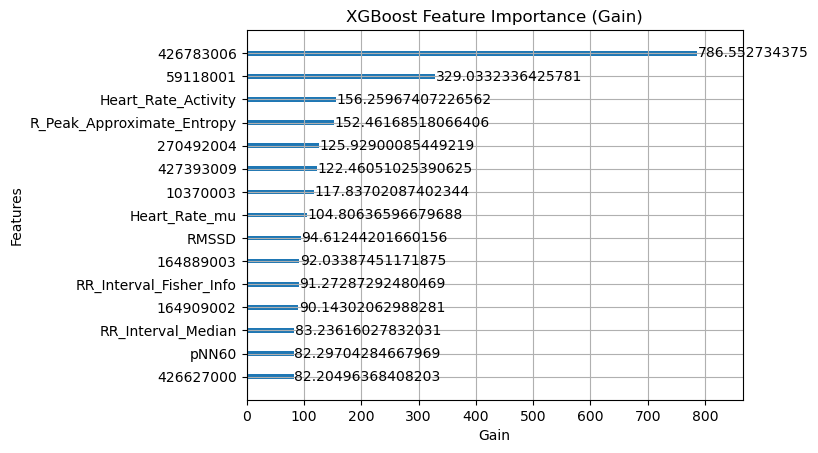

In [52]:
xgb.plot_importance(model, importance_type='gain', max_num_features=15, title="XGBoost Feature Importance (Gain)", xlabel="Gain", ylabel="Features")

In [55]:
snowmed_map

{'270492004': {'Dx': '1st degree av block', 'Abbreviation': 'IAVB'},
 '195042002': {'Dx': '2nd degree av block', 'Abbreviation': 'IIAVB'},
 '164951009': {'Dx': 'abnormal QRS', 'Abbreviation': 'abQRS'},
 '426664006': {'Dx': 'accelerated junctional rhythm', 'Abbreviation': 'AJR'},
 '57054005': {'Dx': 'acute myocardial infarction', 'Abbreviation': 'AMI'},
 '413444003': {'Dx': 'acute myocardial ischemia', 'Abbreviation': 'AMIs'},
 '426434006': {'Dx': 'anterior ischemia', 'Abbreviation': 'AnMIs'},
 '54329005': {'Dx': 'anterior myocardial infarction', 'Abbreviation': 'AnMI'},
 '251173003': {'Dx': 'atrial bigeminy', 'Abbreviation': 'AB'},
 '164889003': {'Dx': 'atrial fibrillation', 'Abbreviation': 'AF'},
 '195080001': {'Dx': 'atrial fibrillation and flutter',
  'Abbreviation': 'AFAFL'},
 '164890007': {'Dx': 'atrial flutter', 'Abbreviation': 'AFL'},
 '195126007': {'Dx': 'atrial hypertrophy', 'Abbreviation': 'AH'},
 '251268003': {'Dx': 'atrial pacing pattern', 'Abbreviation': 'AP'},
 '713422000

In [59]:
# --- Define the function to convert or keep text ---
def get_dx_description(feature_value, mapping_dict):
    """
    Attempts to convert a feature value (SNOMED CT code string) to its
    'Dx' description using the mapping_dict.
    If the value is not a valid numeric string representing a code,
    or if the code is not in the map, it handles it gracefully.
    """
    # 1. Check if the value is a string and can be converted to an integer
    # This helps differentiate numeric codes from general text.
    if isinstance(feature_value, str) and feature_value.isdigit():
        # It's a string that looks like a number (potential SNOMED code)
        code_str = feature_value
        if code_str in mapping_dict:
            return mapping_dict[code_str].get('Dx', 'Dx Not Found in Inner Dict')
        else:
            # It's a numeric string but not in our mapping
            return 'Unknown SNOMED Code'
    else:
        # It's not a numeric string (e.g., 'Some text', None, actual numbers)
        # We want to keep these as they are.
        return feature_value
importance_df_gain["Features_mapped"] = importance_df_gain['Feature'].apply(lambda x: get_dx_description(x, snowmed_map))

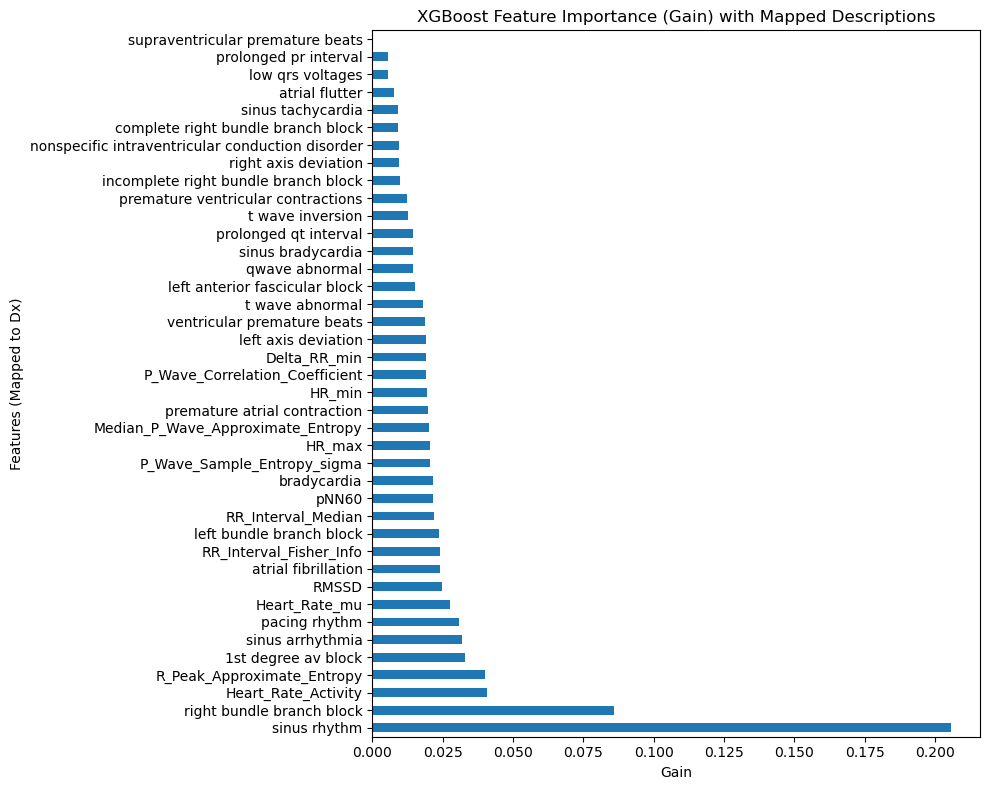

In [63]:
# Plot the feature importance with the mapped descriptions
importance_df_gain['Features_mapped'] = importance_df_gain['Features_mapped'].astype(str)  # Ensure all are strings for plotting
# Now just plot importance_df_gain
import matplotlib.pyplot as plt
importance_df_gain.set_index('Features_mapped', inplace=True)
importance_df_gain['Importance_Gain'].plot(kind='barh', figsize=(10, 8))
plt.title("XGBoost Feature Importance (Gain) with Mapped Descriptions")
plt.xlabel("Gain")
plt.ylabel("Features (Mapped to Dx)")
plt.tight_layout()
plt.show()